In [1]:
import pandas as pd

df = pd.read_csv('data.csv', sep=';')

In [2]:
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
for col in df.columns:
    print(f"🔹 {col} ({df[col].nunique()} benzersiz değer):")
    print("   Örnek Değerler:", df[col].unique()[:5])
    print("-" * 50)

🔹 Marital status (6 benzersiz değer):
   Örnek Değerler: [1 2 4 3 5]
--------------------------------------------------
🔹 Application mode (18 benzersiz değer):
   Örnek Değerler: [17 15  1 39 18]
--------------------------------------------------
🔹 Application order (8 benzersiz değer):
   Örnek Değerler: [5 1 2 4 3]
--------------------------------------------------
🔹 Course (17 benzersiz değer):
   Örnek Değerler: [ 171 9254 9070 9773 8014]
--------------------------------------------------
🔹 Daytime/evening attendance	 (2 benzersiz değer):
   Örnek Değerler: [1 0]
--------------------------------------------------
🔹 Previous qualification (17 benzersiz değer):
   Örnek Değerler: [ 1 19 42 39 10]
--------------------------------------------------
🔹 Previous qualification (grade) (101 benzersiz değer):
   Örnek Değerler: [122.  160.  100.  133.1 142. ]
--------------------------------------------------
🔹 Nacionality (21 benzersiz değer):
   Örnek Değerler: [ 1 62  6 41 26]
----------

In [4]:
missing = df.isnull().sum()
missing

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df['Target'].value_counts(normalize=True) * 100

Target
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64

In [7]:
df[['Age at enrollment', 'Admission grade', 
    'Curricular units 1st sem (grade)', 
    'Curricular units 2nd sem (grade)']].describe().T

,count,mean,std,min,25%,50%,75%,max
Age at enrollment,4424.0,23.265145,7.587816,17.0,19.00,20.000000,25.000000,70.000000
Admission grade,4424.0,126.978119,14.482001,95.0,117.90,126.100000,134.800000,190.000000
Curricular units 1st sem (grade),4424.0,10.640822,4.843663,0.0,11.00,12.285714,13.400000,18.875000
Curricular units 2nd sem (grade),4424.0,10.230206,5.210808,0.0,10.75,12.200000,13.333333,18.571429


In [8]:
df.groupby('Target')[['Curricular units 1st sem (approved)', 
                      'Curricular units 2nd sem (approved)', 
                      'Admission grade', 
                      'Age at enrollment']].mean()

,Curricular units 1st sem (approved),Curricular units 2nd sem (approved),Admission grade,Age at enrollment
Target,,,,
Dropout,2.551724,1.940183,124.961365,26.068966
Enrolled,4.318640,4.057935,125.534257,22.369018
Graduate,6.232232,6.177003,128.794432,21.783612


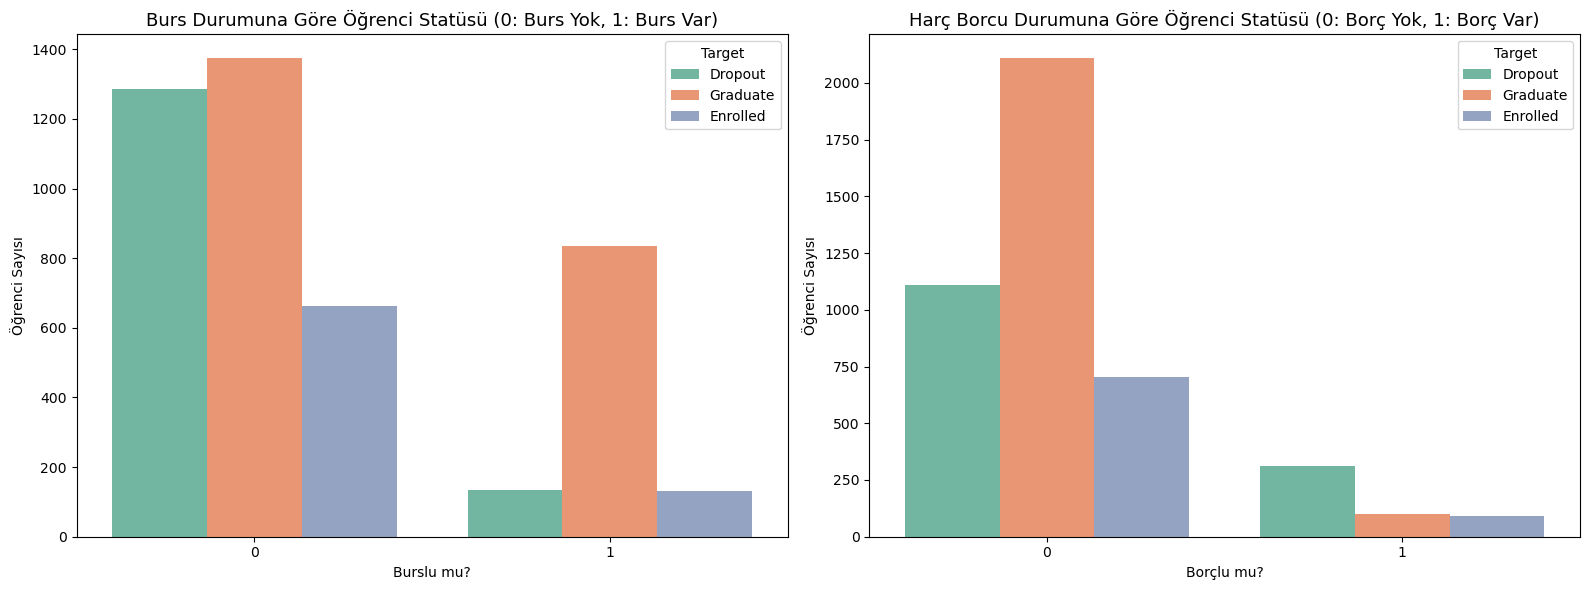

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(ax=axes[0], x='Scholarship holder', hue='Target', data=df, palette='Set2')
axes[0].set_title('Burs Durumuna Göre Öğrenci Statüsü (0: Burs Yok, 1: Burs Var)', fontsize=13)
axes[0].set_xlabel('Burslu mu?')
axes[0].set_ylabel('Öğrenci Sayısı')

sns.countplot(ax=axes[1], x='Debtor', hue='Target', data=df, palette='Set2')
axes[1].set_title('Harç Borcu Durumuna Göre Öğrenci Statüsü (0: Borç Yok, 1: Borç Var)', fontsize=13)
axes[1].set_xlabel('Borçlu mu?')
axes[1].set_ylabel('Öğrenci Sayısı')

plt.tight_layout()
plt.show()

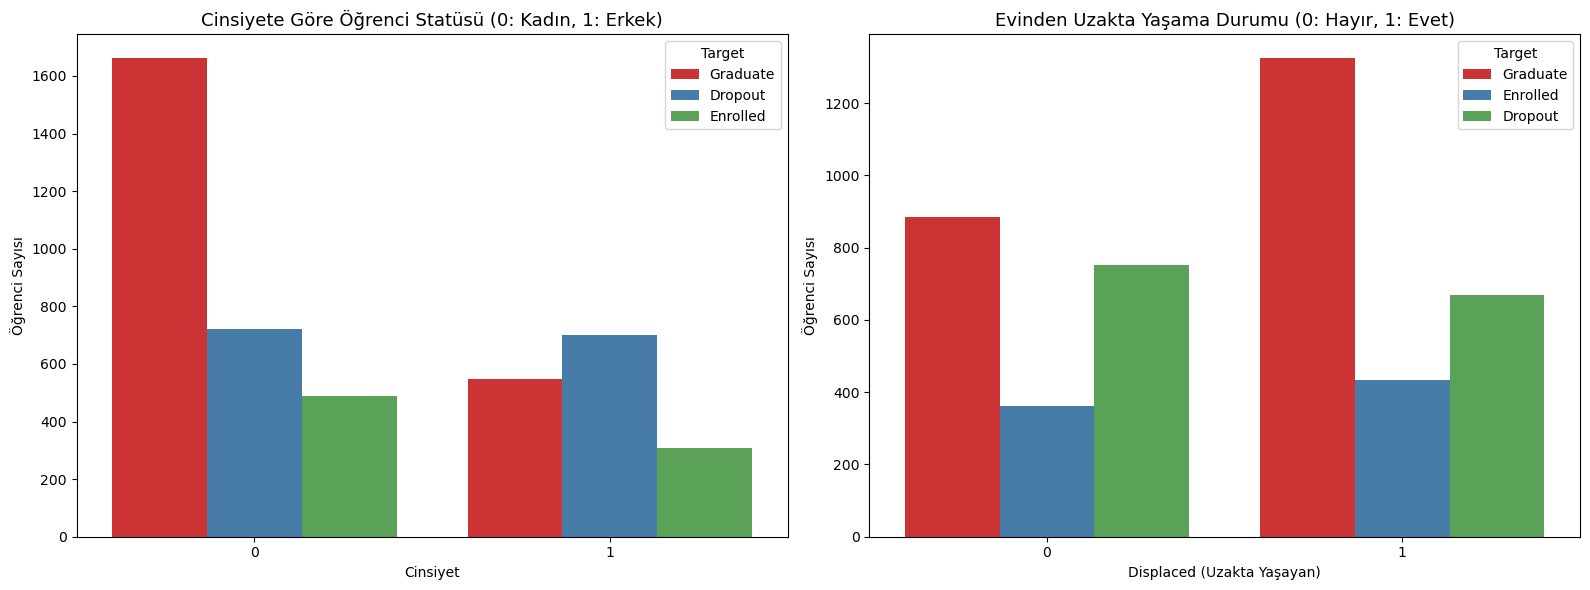

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(ax=axes[0], x='Gender', hue='Target', data=df, palette='Set1')
axes[0].set_title('Cinsiyete Göre Öğrenci Statüsü (0: Kadın, 1: Erkek)', fontsize=13)
axes[0].set_xlabel('Cinsiyet')
axes[0].set_ylabel('Öğrenci Sayısı')

sns.countplot(ax=axes[1], x='Displaced', hue='Target', data=df, palette='Set1')
axes[1].set_title('Evinden Uzakta Yaşama Durumu (0: Hayır, 1: Evet)', fontsize=13)
axes[1].set_xlabel('Displaced (Uzakta Yaşayan)')
axes[1].set_ylabel('Öğrenci Sayısı')

plt.tight_layout()
plt.show()

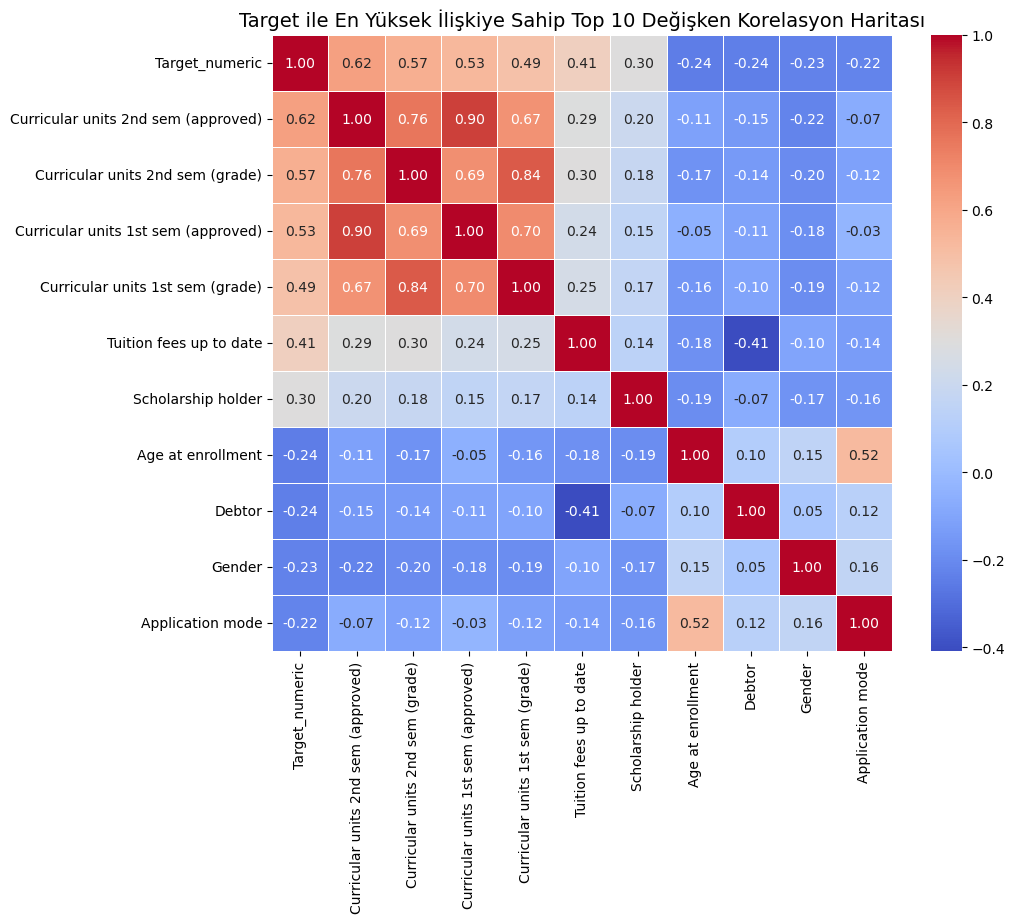

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

target_map = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df['Target_numeric'] = df['Target'].map(target_map)

corr_matrix = df.select_dtypes(include=[np.number]).corr()

top_corr_features = corr_matrix['Target_numeric'].abs().sort_values(ascending=False)[1:11].index

plt.figure(figsize=(10, 8))
sns.heatmap(df[top_corr_features.insert(0, 'Target_numeric')].corr(), 
            annot=True, 
            cmap='coolwarm', 
            fmt='.2f', 
            linewidths=0.5)

plt.title('Target ile En Yüksek İlişkiye Sahip Top 10 Değişken Korelasyon Haritası', fontsize=14)
plt.show()

In [12]:
df['total_units_approved'] = df['Curricular units 1st sem (approved)'] + df['Curricular units 2nd sem (approved)']

df['total_units_enrolled'] = df['Curricular units 1st sem (enrolled)'] + df['Curricular units 2nd sem (enrolled)']

df['overall_success_rate'] = np.where(
    df['total_units_enrolled'] > 0,
    df['total_units_approved'] / df['total_units_enrolled'],
    0
)

df['grade_trend'] = df['Curricular units 2nd sem (grade)'] - df['Curricular units 1st sem (grade)']

df[['total_units_approved', 'overall_success_rate', 'grade_trend']].head()

,total_units_approved,overall_success_rate,grade_trend
0,0,0.000000,0.000000
1,12,1.000000,-0.333333
2,0,0.000000,0.000000
3,11,0.916667,-1.028571
4,11,0.916667,0.666667


In [13]:
df['sem2_eval_efficiency'] = np.where(
    df['Curricular units 2nd sem (evaluations)'] > 0,
    df['Curricular units 2nd sem (approved)'] / df['Curricular units 2nd sem (evaluations)'],
    0
)

In [14]:
df['sem1_eval_efficiency'] = np.where(
    df['Curricular units 1st sem (evaluations)'] > 0,
    df['Curricular units 1st sem (approved)'] / df['Curricular units 1st sem (evaluations)'],
    0
)

In [15]:
df[['sem1_eval_efficiency', 'sem2_eval_efficiency']].head()

,sem1_eval_efficiency,sem2_eval_efficiency
0,0.000000,0.0
1,1.000000,1.0
2,0.000000,0.0
3,0.750000,0.5
4,0.555556,1.0


In [16]:
df['total_units_approved'] = df['Curricular units 1st sem (approved)'] + df['Curricular units 2nd sem (approved)']

In [17]:
df['total_units_enrolled'] = df['Curricular units 1st sem (enrolled)'] + df['Curricular units 2nd sem (enrolled)']

In [18]:
df['overall_success_rate'] = np.where(
    df['total_units_enrolled'] > 0,
    df['total_units_approved'] / df['total_units_enrolled'],
    0
)

In [19]:
df[['total_units_approved', 'total_units_enrolled' , 'overall_success_rate']].head()

,total_units_approved,total_units_enrolled,overall_success_rate
0,0,0,0.000000
1,12,12,1.000000
2,0,12,0.000000
3,11,12,0.916667
4,11,12,0.916667


In [20]:
df['financial_risk_score'] = df['Debtor'] + (1 - df['Tuition fees up to date']) + (1 - df['Scholarship holder'])
df['financial_risk_score'].head()

0    1
1    2
2    2
3    1
4    1
Name: financial_risk_score, dtype: int64

In [21]:
df['first_year_grade_avg'] = (df['Curricular units 1st sem (grade)'] + df['Curricular units 2nd sem (grade)']) / 2
df['first_year_grade_avg'].head()

0     0.000000
1    13.833333
2     0.000000
3    12.914286
4    12.666667
Name: first_year_grade_avg, dtype: float64

In [22]:
df['grade_trend'] = df['Curricular units 2nd sem (grade)'] - df['Curricular units 1st sem (grade)']
df['grade_trend'].head()

0    0.000000
1   -0.333333
2    0.000000
3   -1.028571
4    0.666667
Name: grade_trend, dtype: float64

TARGET İLE EN YÜKSEK KORELASYONA SAHİP TOP 12 DEĞİŞKEN
sem2_eval_efficiency                   0.692
overall_success_rate                   0.686
sem1_eval_efficiency                   0.632
Curricular units 2nd sem (approved)    0.624
total_units_approved                   0.590
Curricular units 2nd sem (grade)       0.567
first_year_grade_avg                   0.550
Curricular units 1st sem (approved)    0.529
Curricular units 1st sem (grade)       0.485
Tuition fees up to date                0.410
Scholarship holder                     0.298
financial_risk_score                  -0.463
Name: Target_numeric, dtype: float64


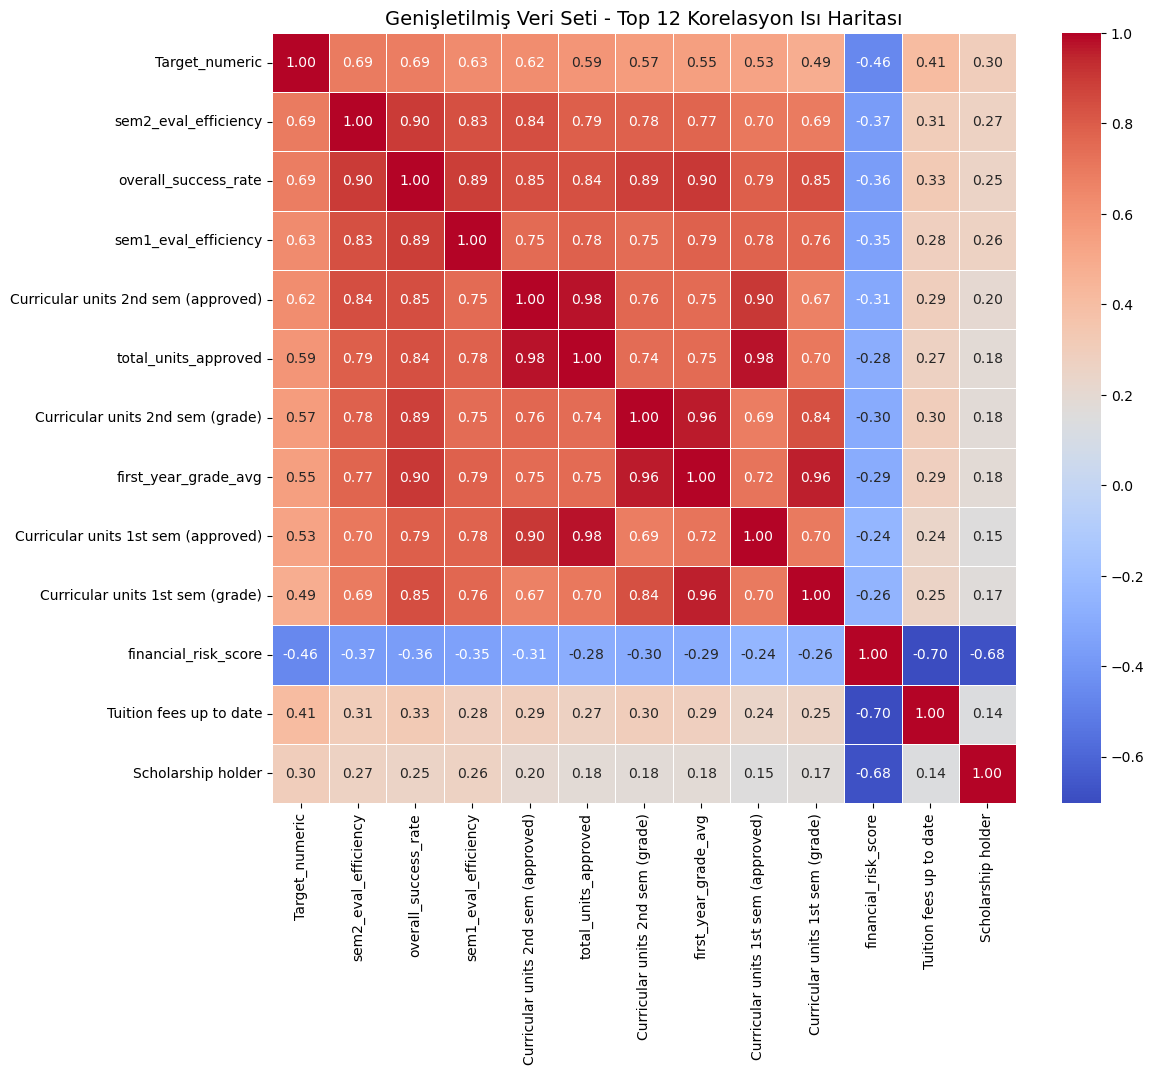

In [23]:
target_map = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df['Target_numeric'] = df['Target'].map(target_map)

corr_matrix = df.select_dtypes(include=[np.number]).corr()

top_12_features = corr_matrix['Target_numeric'].abs().sort_values(ascending=False)[1:13].index

print("TARGET İLE EN YÜKSEK KORELASYONA SAHİP TOP 12 DEĞİŞKEN")
top_12_corr_values = corr_matrix.loc[top_12_features, 'Target_numeric'].sort_values(ascending=False)
print(top_12_corr_values.round(3))

plt.figure(figsize=(12, 10))
sns.heatmap(
    df[top_12_features.insert(0, 'Target_numeric')].corr(), 
    annot=True, 
    cmap='coolwarm', 
    fmt='.2f', 
    linewidths=0.5,
    cbar=True
)

plt.title('Genişletilmiş Veri Seti - Top 12 Korelasyon Isı Haritası', fontsize=14)
plt.show()

# 6. İşimiz bittiğinde geçici Target_numeric sütununu silelim
df = df.drop(columns=['Target_numeric'])

/var/folders/h_/4cvl86mn0lg7cfm1sm5bc48c0000gn/T/ipykernel_19983/2174437464.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.head(15), y=feature_importances.head(15).index, palette='viridis')


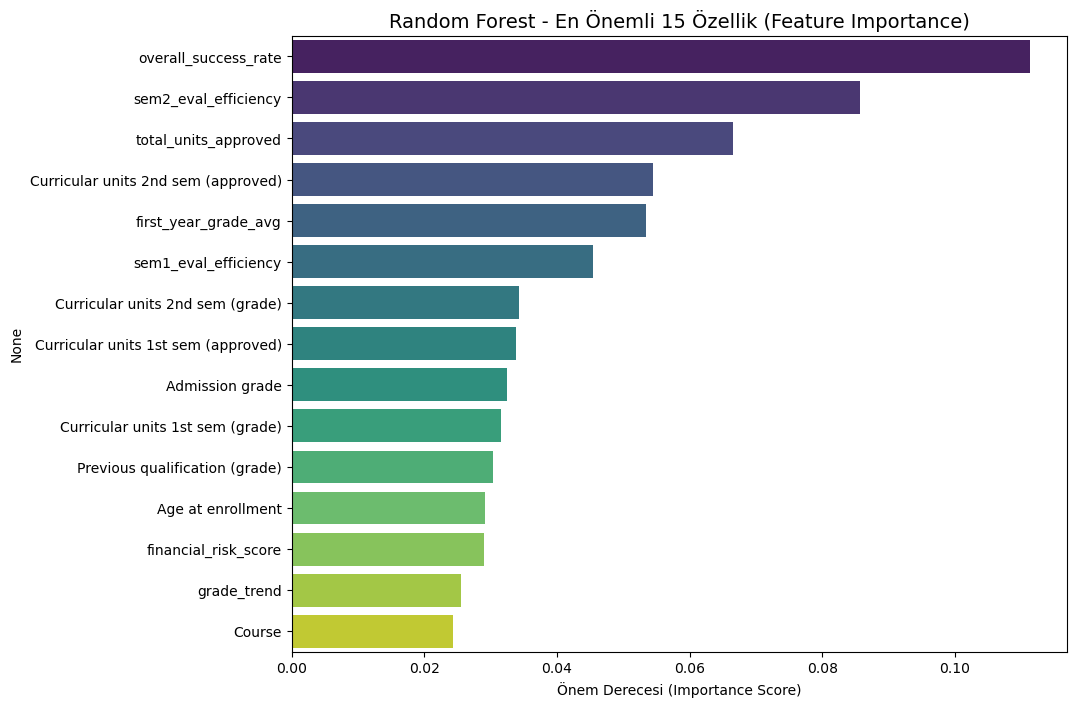

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

X = df.drop(columns=['Target'])
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=feature_importances.head(15), y=feature_importances.head(15).index, palette='viridis')
plt.title('Random Forest - En Önemli 15 Özellik (Feature Importance)', fontsize=14)
plt.xlabel('Önem Derecesi (Importance Score)')
plt.show()

In [25]:
top_n = 10  

selected_features = feature_importances.head(top_n).index

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print(f"Seçilen Özellikler ({len(selected_features)} Adet):\n", list(selected_features))

Seçilen Özellikler (10 Adet):
 ['overall_success_rate', 'sem2_eval_efficiency', 'total_units_approved', 'Curricular units 2nd sem (approved)', 'first_year_grade_avg', 'sem1_eval_efficiency', 'Curricular units 2nd sem (grade)', 'Curricular units 1st sem (approved)', 'Admission grade', 'Curricular units 1st sem (grade)']


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_selected)

X_test_scaled = scaler.transform(X_test_selected)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=selected_features, index=X_train_selected.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=selected_features, index=X_test_selected.index)



In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_selected)

X_test_scaled = scaler.transform(X_test_selected)

In [43]:
import joblib
import shap
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
)

device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))

In [44]:
target_col_name = y.name if hasattr(y, 'name') and y.name is not None else 'Target'
df_temp = pd.concat([X, y], axis=1)

if df_temp[target_col_name].dtype == 'object' or isinstance(df_temp[target_col_name].iloc[0], str):
    df_filtered = df_temp[df_temp[target_col_name] != 'Enrolled'].copy()
else:
    df_filtered = df_temp[df_temp[target_col_name] != 1].copy()

X_filtered = df_filtered.drop(columns=[target_col_name])
y_filtered = df_filtered[target_col_name]

X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, 
    test_size=0.20, 
    random_state=42, 
    stratify=y_filtered
)

In [45]:
rf_temp = RandomForestClassifier(random_state=42).fit(X_train, y_train)
feature_importances = pd.Series(rf_temp.feature_importances_, index=X_train.columns).sort_values(ascending=False)

cumsum_importances = feature_importances.cumsum()
threshold = 0.98  
selected_features = cumsum_importances[cumsum_importances.shift(1, fill_value=0) < threshold].index

X_train_base = X_train[selected_features].copy()
X_test_base = X_test[selected_features].copy()

top_5_features = feature_importances.head(5).index.tolist()

def create_engineered_features(df, top_cols):
    df_new = df.copy()
    for i in range(len(top_cols)):
        for j in range(i + 1, len(top_cols)):
            col1 = top_cols[i]
            col2 = top_cols[j]
            df_new[f"{col1}_x_{col2}"] = df_new[col1] * df_new[col2]
            df_new[f"{col1}_ratio_{col2}"] = df_new[col1] / (df_new[col2] + 1e-5)
    
    num_cols = df.select_dtypes(include=[np.number]).columns
    df_new['row_mean'] = df[num_cols].mean(axis=1)
    df_new['row_std'] = df[num_cols].std(axis=1)
    df_new['row_median'] = df[num_cols].median(axis=1)
    return df_new

X_train_selected = create_engineered_features(X_train_base, top_5_features)
X_test_selected = create_engineered_features(X_test_base, top_5_features)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

In [46]:
models = {
    'Logistic Regression': {'model': LogisticRegression(random_state=42, max_iter=1000), 'use_scaled': True},
    'Support Vector Machine (SVM)': {'model': SVC(random_state=42, probability=True), 'use_scaled': True},
    'Random Forest': {'model': RandomForestClassifier(random_state=42), 'use_scaled': False},
    'LightGBM': {'model': LGBMClassifier(random_state=42, verbose=-1), 'use_scaled': False}
}

results = []
trained_models = {}

for name, config in models.items():
    model = config['model']
    use_scaled = config['use_scaled']
    
    X_tr = X_train_scaled if use_scaled else X_train_selected
    X_te = X_test_scaled if use_scaled else X_test_selected
    
    model.fit(X_tr, y_train)
    trained_models[name] = model
    
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te) if hasattr(model, "predict_proba") else None
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, average='weighted', zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_proba[:, 1] if y_proba.shape[1] == 2 else y_proba) if y_proba is not None else None
    })

if isinstance(y_train.iloc[0] if hasattr(y_train, 'iloc') else y_train[0], str):
    unique_labels = np.unique(y_train)
    label_map = {val: idx for idx, val in enumerate(unique_labels)}
    y_train_num = np.array([label_map[item] for item in y_train])
    y_test_num = np.array([label_map[item] for item in y_test])
else:
    y_train_num, y_test_num = np.array(y_train), np.array(y_test)

train_loader = DataLoader(TensorDataset(torch.tensor(X_train_scaled, dtype=torch.float32), torch.tensor(y_train_num, dtype=torch.long)), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test_scaled, dtype=torch.float32), torch.tensor(y_test_num, dtype=torch.long)), batch_size=128, shuffle=False)

class DeepMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(DeepMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.SiLU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.SiLU(), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.BatchNorm1d(32), nn.SiLU(), nn.Dropout(0.2),
            nn.Linear(32, num_classes)
        )
    def forward(self, x): return self.network(x)

dl_model = DeepMLP(X_train_scaled.shape[1], len(np.unique(y_train_num))).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(dl_model.parameters(), lr=0.001, weight_decay=1e-4)

for epoch in range(60):
    dl_model.train()
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        loss = criterion(dl_model(bx), by)
        loss.backward()
        optimizer.step()

dl_model.eval()
y_probs_list = []
with torch.no_grad():
    for bx, _ in test_loader:
        y_probs_list.append(torch.softmax(dl_model(bx.to(device)), dim=1).cpu().numpy())

y_proba_dl = np.vstack(y_probs_list)
y_pred_dl = np.argmax(y_proba_dl, axis=1)

results.append({
    'Model': 'PyTorch Deep MLP',
    'Accuracy': accuracy_score(y_test_num, y_pred_dl),
    'Precision': precision_score(y_test_num, y_pred_dl, average='weighted', zero_division=0),
    'Recall': recall_score(y_test_num, y_pred_dl, average='weighted', zero_division=0),
    'F1-Score': f1_score(y_test_num, y_pred_dl, average='weighted', zero_division=0),
    'ROC-AUC': roc_auc_score(y_test_num, y_proba_dl[:, 1])
})

results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,PyTorch Deep MLP,0.920110,0.921103,0.920110,0.919335,0.947366
1,Support Vector Machine (SVM),0.918733,0.922013,0.918733,0.917454,0.946068
2,Logistic Regression,0.917355,0.919544,0.917355,0.916255,0.949589
3,Random Forest,0.914601,0.916025,0.914601,0.913621,0.954524
4,LightGBM,0.914601,0.916701,0.914601,0.913463,0.952863


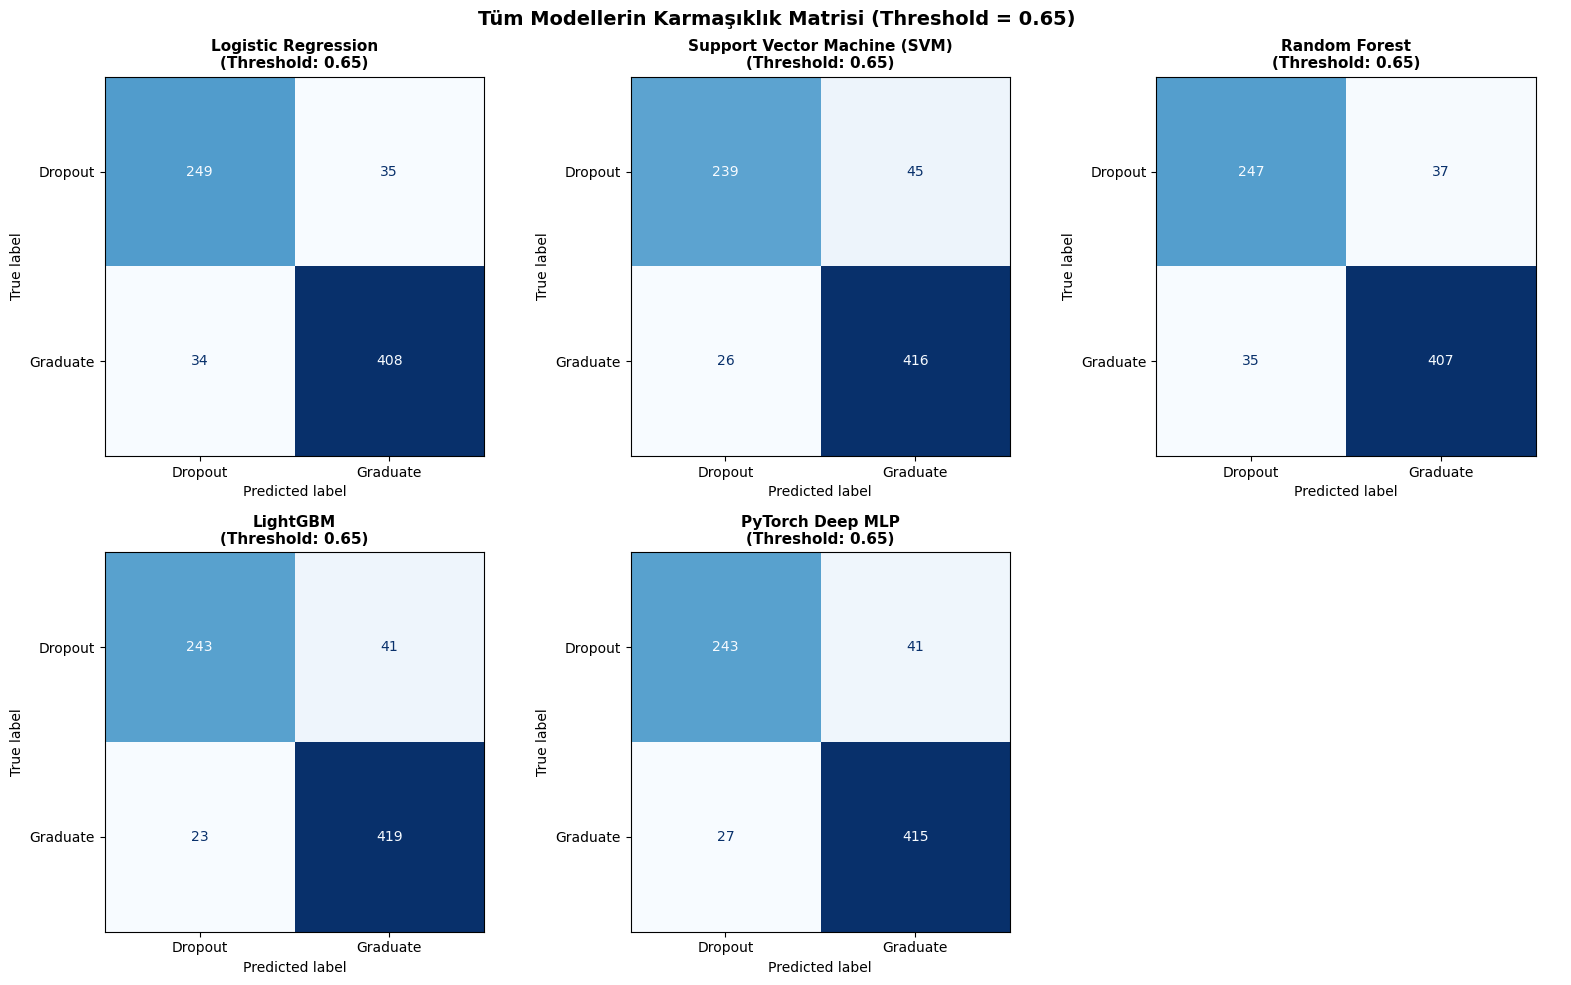

In [47]:
classes = np.unique(y_test)
grad_label = 'Graduate' if 'Graduate' in classes else 1
drop_label = 'Dropout' if 'Dropout' in classes else 0

model_probs = {}
for name, config in models.items():
    model = trained_models[name]
    X_te = X_test_scaled if config['use_scaled'] else X_test_selected
    probs = model.predict_proba(X_te)
    grad_idx = np.where(model.classes_ == grad_label)[0][0] if hasattr(model, "classes_") else 1
    model_probs[name] = probs[:, grad_idx]

grad_num_idx = label_map[grad_label] if 'label_map' in globals() and grad_label in label_map else 1
model_probs['PyTorch Deep MLP'] = y_proba_dl[:, grad_num_idx]

# 2x3 Alt Grafik Izgarası
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes = axes.flatten()
CUSTOM_THRESHOLD = 0.65 

for idx, (model_name, probs) in enumerate(model_probs.items()):
    ax = axes[idx]
    preds = np.where(probs >= CUSTOM_THRESHOLD, grad_label, drop_label)
    cm = confusion_matrix(y_test, preds, labels=[drop_label, grad_label])
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[drop_label, grad_label])
    disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d', colorbar=False)
    
    ax.set_title(f"{model_name}\n(Threshold: {CUSTOM_THRESHOLD})", fontsize=11, fontweight='bold')
    ax.grid(False)

axes[5].axis('off')
plt.suptitle("Tüm Modellerin Karmaşıklık Matrisi (Threshold = 0.65)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [48]:
for model_name, probs in model_probs.items():
    preds = np.where(probs >= CUSTOM_THRESHOLD, grad_label, drop_label)
    print(f"\n>>> MODEL: {model_name} (Threshold = {CUSTOM_THRESHOLD}) <<<")
    print(classification_report(y_test, preds, digits=4))


>>> MODEL: Logistic Regression (Threshold = 0.65) <<<
              precision    recall  f1-score   support

     Dropout     0.8799    0.8768    0.8783       284
    Graduate     0.9210    0.9231    0.9220       442

    accuracy                         0.9050       726
   macro avg     0.9004    0.8999    0.9002       726
weighted avg     0.9049    0.9050    0.9049       726


>>> MODEL: Support Vector Machine (SVM) (Threshold = 0.65) <<<
              precision    recall  f1-score   support

     Dropout     0.9019    0.8415    0.8707       284
    Graduate     0.9024    0.9412    0.9214       442

    accuracy                         0.9022       726
   macro avg     0.9021    0.8914    0.8960       726
weighted avg     0.9022    0.9022    0.9015       726


>>> MODEL: Random Forest (Threshold = 0.65) <<<
              precision    recall  f1-score   support

     Dropout     0.8759    0.8697    0.8728       284
    Graduate     0.9167    0.9208    0.9187       442

    accuracy  

In [49]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_models = {
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Support Vector Machine (SVM)': SVC(random_state=42, probability=True)
}

cv_summary_results = []

for model_name, model_obj in cv_models.items():
    acc_list, prec_list, rec_list, f1_list, auc_list = [], [], [], [], []
    
    for train_idx, val_idx in cv.split(X_filtered, y_filtered):
        X_train_fold, X_val_fold = X_filtered.iloc[train_idx].copy(), X_filtered.iloc[val_idx].copy()
        y_train_fold, y_val_fold = y_filtered.iloc[train_idx], y_filtered.iloc[val_idx]
        
        rf_f = RandomForestClassifier(random_state=42).fit(X_train_fold, y_train_fold)
        top5 = pd.Series(rf_f.feature_importances_, index=X_train_fold.columns).sort_values(ascending=False).head(5).index.tolist()
        
        X_tr_eng = create_engineered_features(X_train_fold, top5)
        X_val_eng = create_engineered_features(X_val_fold, top5)
        
        if model_name in ['Logistic Regression', 'Support Vector Machine (SVM)']:
            s_fold = StandardScaler()
            X_tr_final = s_fold.fit_transform(X_tr_eng)
            X_val_final = s_fold.transform(X_val_eng)
        else:
            X_tr_final, X_val_final = X_tr_eng.values, X_val_eng.values
            
        model_obj.fit(X_tr_final, y_train_fold)
        probs = model_obj.predict_proba(X_val_final)
        grad_idx = np.where(model_obj.classes_ == grad_label)[0][0] if hasattr(model_obj, "classes_") else 1
        grad_probs = probs[:, grad_idx]
        
        preds = np.where(grad_probs >= CUSTOM_THRESHOLD, grad_label, drop_label)
        
        acc_list.append(accuracy_score(y_val_fold, preds))
        prec_list.append(precision_score(y_val_fold, preds, pos_label=drop_label, average='binary', zero_division=0))
        rec_list.append(recall_score(y_val_fold, preds, pos_label=drop_label, average='binary', zero_division=0))
        f1_list.append(f1_score(y_val_fold, preds, pos_label=drop_label, average='binary', zero_division=0))
        auc_list.append(roc_auc_score(y_val_fold, grad_probs))
        
    cv_summary_results.append({
        'Model': model_name,
        'Mean Accuracy': f"%{np.mean(acc_list)*100:.2f} ± {np.std(acc_list)*100:.2f}",
        'Dropout Recall': f"%{np.mean(rec_list)*100:.2f} ± {np.std(rec_list)*100:.2f}",
        'Dropout Precision': f"%{np.mean(prec_list)*100:.2f} ± {np.std(prec_list)*100:.2f}",
        'Dropout F1-Score': f"%{np.mean(f1_list)*100:.2f} ± {np.std(f1_list)*100:.2f}",
        'Mean ROC-AUC': f"{np.mean(auc_list):.4f}"
    })

cv_results_df = pd.DataFrame(cv_summary_results).sort_values(by='Mean Accuracy', ascending=False).reset_index(drop=True)
display(cv_results_df)

,Model,Mean Accuracy,Dropout Recall,Dropout Precision,Dropout F1-Score,Mean ROC-AUC
0,LightGBM,%91.52 ± 1.01,%87.62 ± 1.90,%90.44 ± 1.63,%88.99 ± 1.32,0.9550
1,Support Vector Machine (SVM),%90.85 ± 0.91,%86.99 ± 2.67,%89.45 ± 2.12,%88.15 ± 1.23,0.9500
2,Random Forest,%90.50 ± 1.46,%89.02 ± 1.86,%87.05 ± 2.35,%88.01 ± 1.77,0.9539
3,Logistic Regression,%90.14 ± 0.89,%88.18 ± 2.07,%86.89 ± 1.95,%87.50 ± 1.10,0.9519


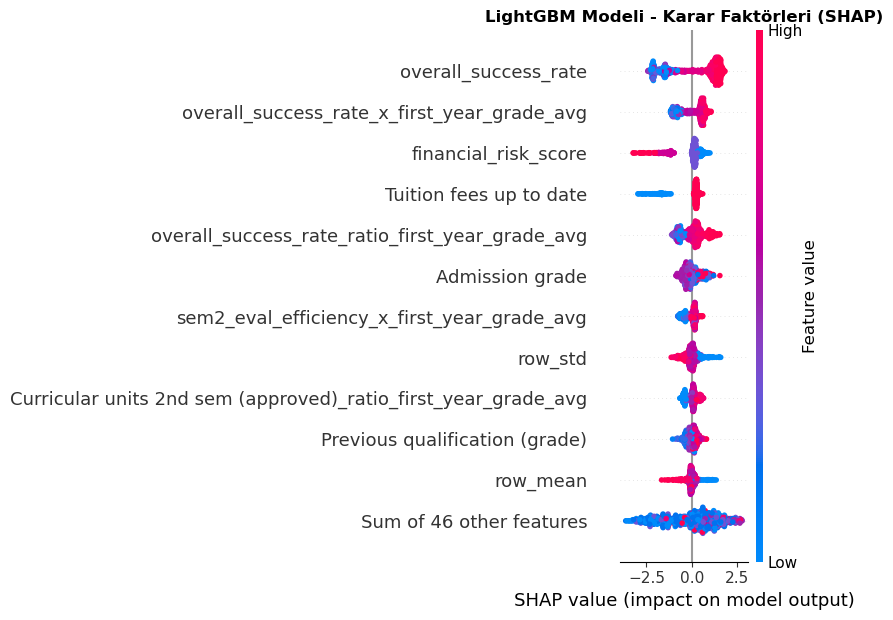

In [50]:
final_model = LGBMClassifier(random_state=42, verbose=-1)
final_model.fit(X_train_selected, y_train)

explainer = shap.TreeExplainer(final_model)
shap_values = explainer(X_test_selected)

plt.figure(figsize=(10, 6))
plt.title("LightGBM Modeli - Karar Faktörleri (SHAP)", fontsize=12, fontweight='bold')
shap.plots.beeswarm(shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values, max_display=12, show=False)
plt.tight_layout()
plt.show()

In [ ]:
joblib.dump(final_model, 'lightgbm_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(list(X_train_selected.columns), 'selected_features.pkl')
joblib.dump(top_5_features, 'top_5_features.pkl')

In [51]:
def predict_student_risk(student_raw_df, threshold=0.65):
    loaded_model = joblib.load('lightgbm_model.pkl')
    loaded_top_5 = joblib.load('top_5_features.pkl')
    expected_cols = joblib.load('selected_features.pkl')
    
    df_engineered = create_engineered_features(student_raw_df, loaded_top_5)
    df_engineered = df_engineered[expected_cols]
    
    grad_idx = np.where(loaded_model.classes_ == 'Graduate')[0][0] if 'Graduate' in loaded_model.classes_ else 1
    grad_probs = loaded_model.predict_proba(df_engineered)[:, grad_idx]
    
    results = []
    for prob in grad_probs:
        dropout_risk_pct = (1.0 - prob) * 100
        if prob >= threshold:
            prediction = 'Graduate (Mezun Olabilir)'
            risk_status = 'DÜŞÜK RİSK'
        else:
            prediction = 'Dropout (Terke Yatkın)'
            risk_status = 'YÜKSEK RİSK (Erken Müdahale Gerekli)'
            
        results.append({
            'Tahmin Etiketi': prediction,
            'Risk Durumu': risk_status,
            'Dropout Risk Yüzdesi': f"%{dropout_risk_pct:.2f}",
            'Graduate Olasılığı': f"%{prob*100:.2f}"
        })
        
    return pd.DataFrame(results)

# Örnek test
sample_students = X_test.head(5)
prediction_report = predict_student_risk(sample_students, threshold=0.65)
display(prediction_report)

,Tahmin Etiketi,Risk Durumu,Dropout Risk Yüzdesi,Graduate Olasılığı
0,Dropout (Terke Yatkın),YÜKSEK RİSK (Erken Müdahale Gerekli),%74.75,%25.25
1,Graduate (Mezun Olabilir),DÜŞÜK RİSK,%0.69,%99.31
2,Graduate (Mezun Olabilir),DÜŞÜK RİSK,%0.39,%99.61
3,Graduate (Mezun Olabilir),DÜŞÜK RİSK,%0.07,%99.93
4,Graduate (Mezun Olabilir),DÜŞÜK RİSK,%1.56,%98.44


In [54]:
X_train_selected.shape[1]

57